# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Fawwaz Prayitno
- Email: fawwazprayitno@gmail.com
- Id Dicoding: fawwaz_Pu1r

## Persiapan

### Menyiapkan library yang dibutuhkan

In [8]:
# =========================
# Manipulation Libraries
# =========================
import pandas as pd
import numpy as np

# =========================
# Visualitation Libraries
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Praprocessing & Modelling Libraries
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =========================
# MODEL EVALUATION libraries
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# =========================
# MODEL SAVING libraries
# =========================
import joblib

# =========================
# STATISTICS / UTILITY
# =========================
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =========================
# DISPLAY SETTINGS
# =========================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### Menyiapkan data yang akan diguankan

## Data Understanding

In [23]:
# =========================
# LOAD DATA
# =========================
df = pd.read_csv('data.csv', sep=';')

# Copy untuk keamanan (hindari overwrite data asli)
df_raw = df.copy()

print("-> Informasi dataset:")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

# =========================
# STRUKTUR DATA
# =========================
display(df.head())

print("\n-> Info Dataset:")
df.info()

print("\n-> Statistik Deskriptif (Numerik):")
display(df.describe().T)

print("\n-> Statistik Deskriptif (Kategorikal):")
display(df.describe(include='object').T)

# =========================
# MISSING VALUES (IMPROVED)
# =========================
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

# Filter hanya yang ada missing
missing_filtered = missing_df[missing_df['Missing Count'] > 0]

if missing_filtered.empty:
    print("Tidak ditemukan missing value pada dataset.")
else:
    print("Ditemukan missing value pada kolom berikut:\n")
    display(missing_filtered.sort_values(by='Missing %', ascending=False))

# =========================
# DUPLICATE DATA
# =========================
duplicates = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicates}")

# Optional: tampilkan sample duplicate
if duplicates > 0:
    display(df[df.duplicated()].head())


# =========================
# OUTLIER DETECTION (IQR)
# =========================
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        'Column': col,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outlier %', ascending=False)

display(outlier_df)



-> Informasi dataset:
Jumlah baris: 4424
Jumlah kolom: 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



-> Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                        

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000



-> Statistik Deskriptif (Kategorikal):


,count,unique,top,freq
Status,4424,3,Graduate,2209


Tidak ditemukan missing value pada dataset.
Jumlah data duplikat: 0


,Column,Outlier Count,Outlier %
18,Scholarship_holder,1099,24.841772
31,Curricular_units_2nd_sem_grade,877,19.823689
25,Curricular_units_1st_sem_grade,726,16.410488
5,Previous_qualification,707,15.981013
21,Curricular_units_1st_sem_credited,577,13.042495
2,Application_order,541,12.228752
27,Curricular_units_2nd_sem_credited,530,11.980108
16,Tuition_fees_up_to_date,528,11.934901
0,Marital_status,505,11.415009
15,Debtor,503,11.369801


## Data Preparation / Preprocessing

Unique Status: ['dropout' 'graduate' 'enrolled']

Distribusi Target (Binary):
Status
0    2209
1    1421
Name: count, dtype: int64
Status
0    0.60854
1    0.39146
Name: proportion, dtype: float64

Train: (2904, 36)
Test: (726, 36)

Numerical Columns: 39
Categorical Columns: 0

Model berhasil dilatih (Binary Classification)


,Count,Percentage (%)
Status,,
0,2209,60.853994
1,1421,39.146006


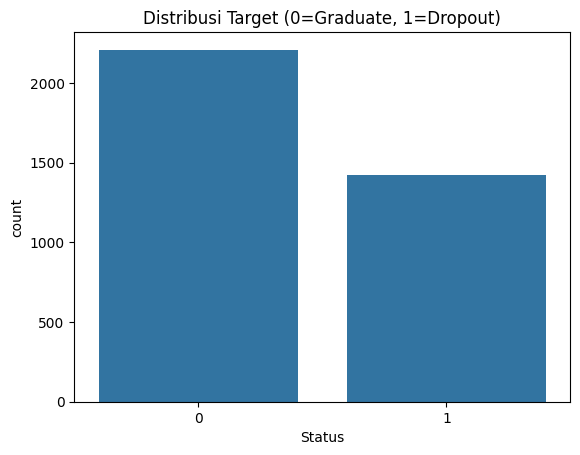

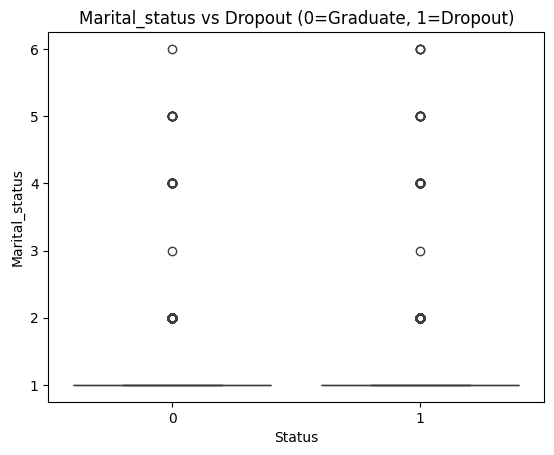

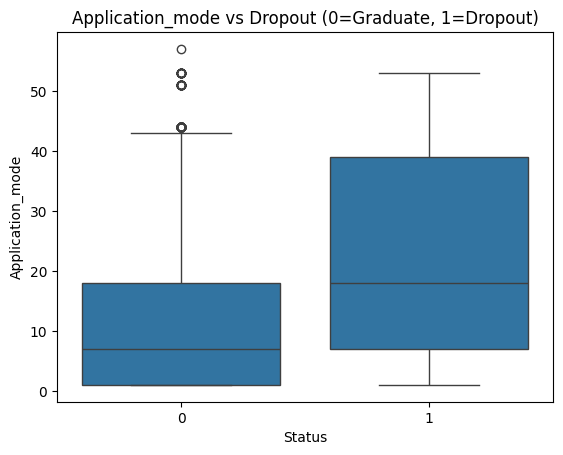

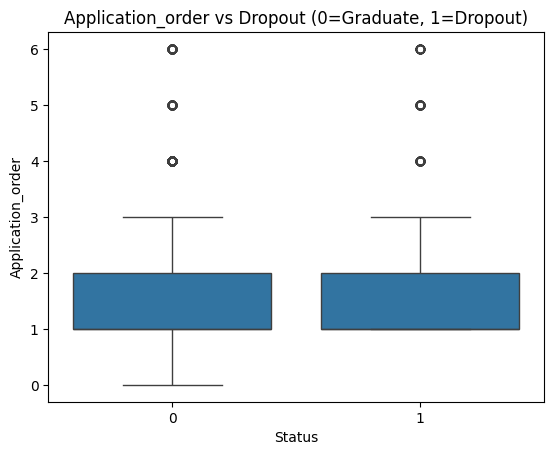

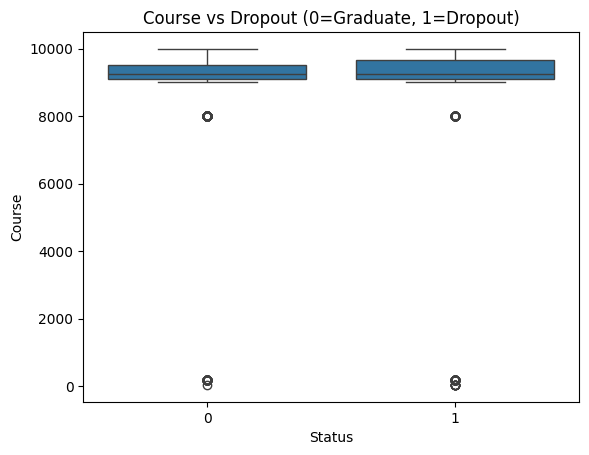

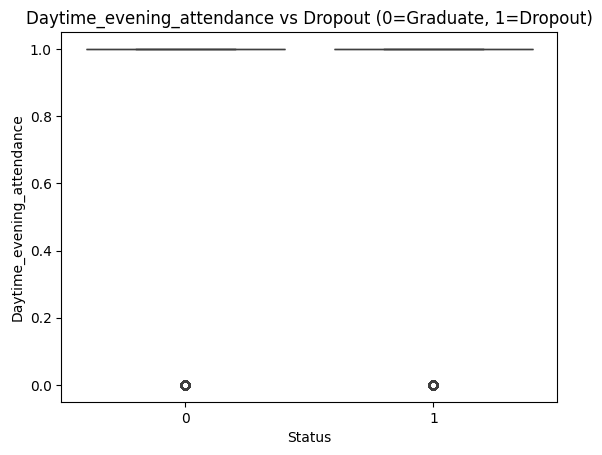

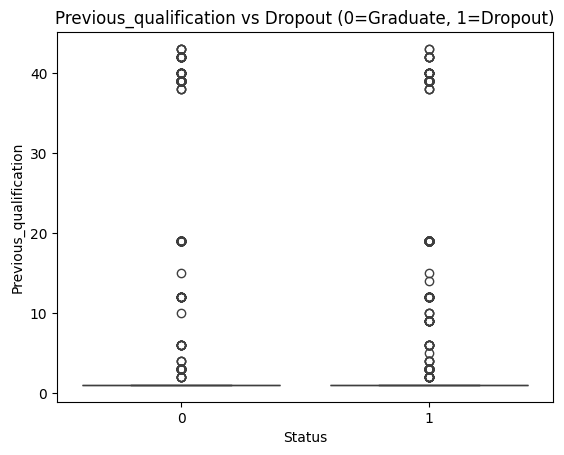

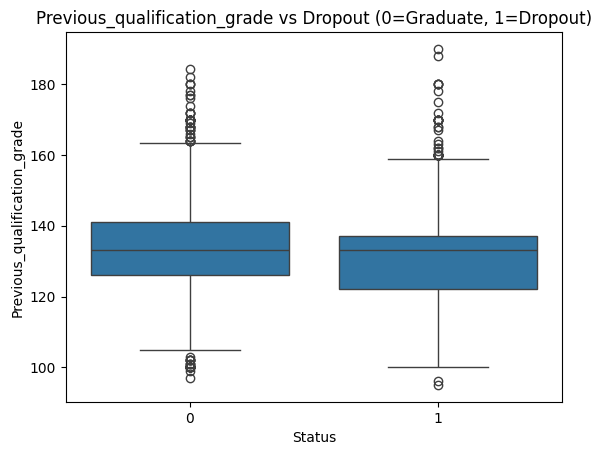

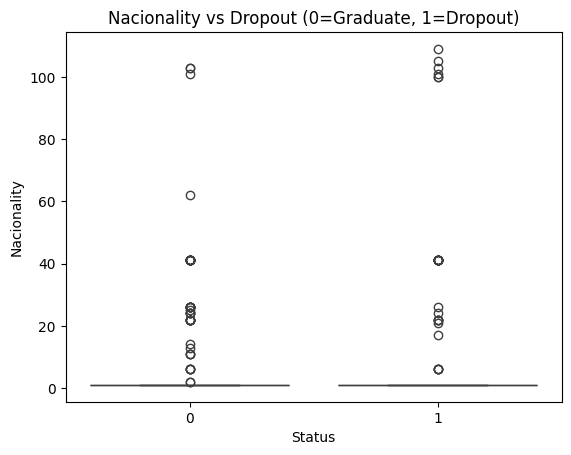

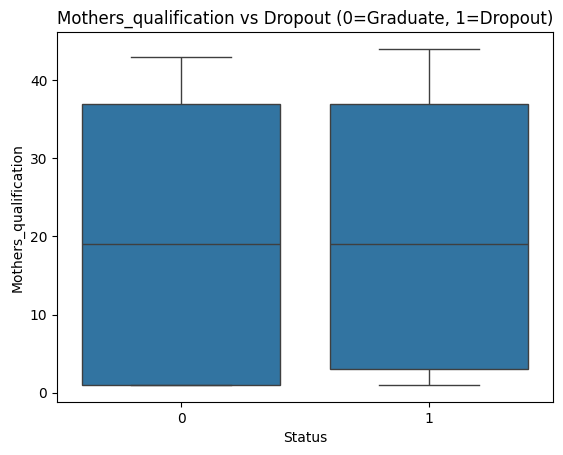

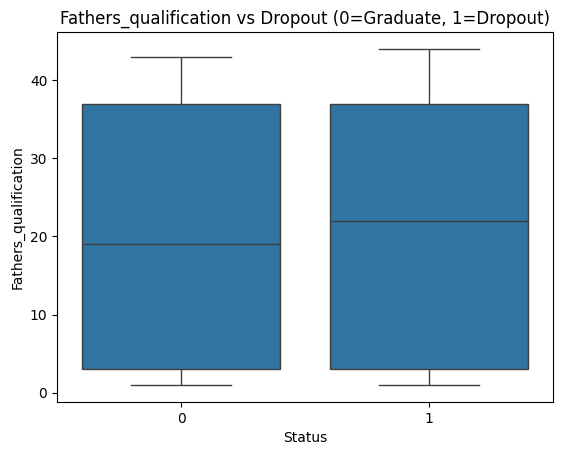

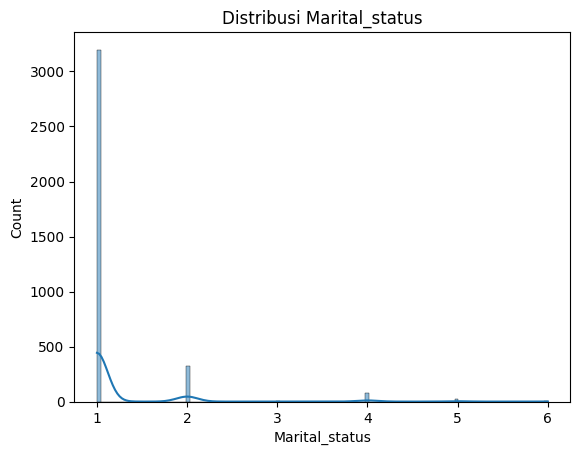

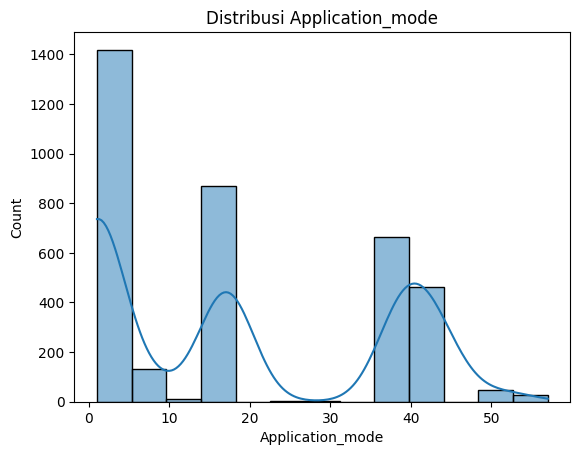

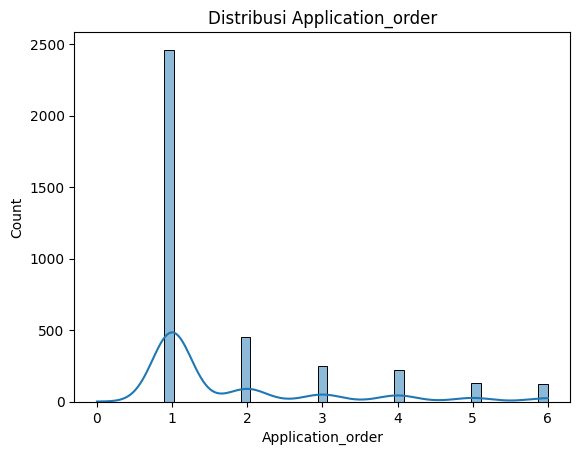

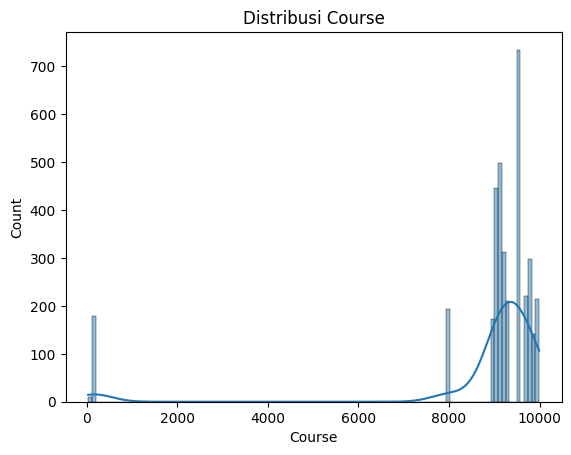

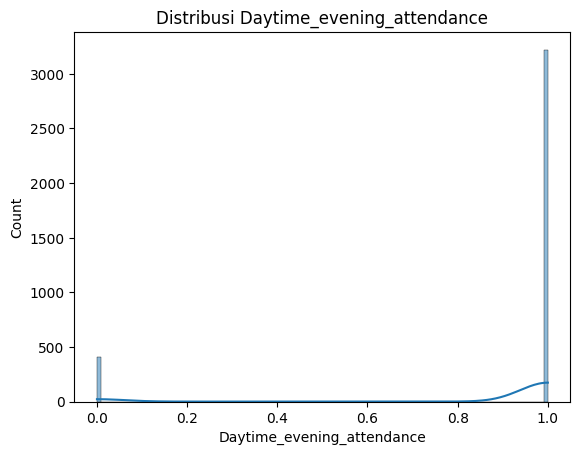

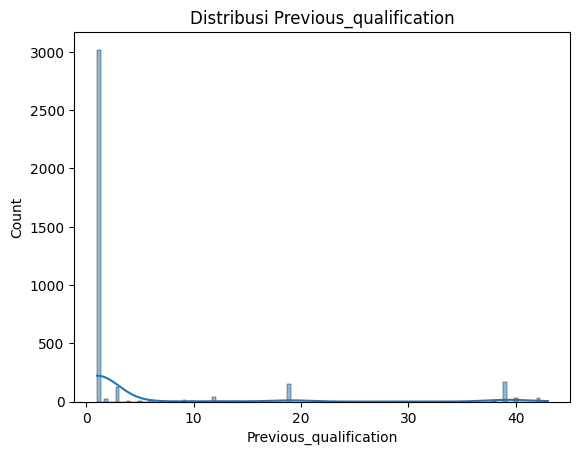

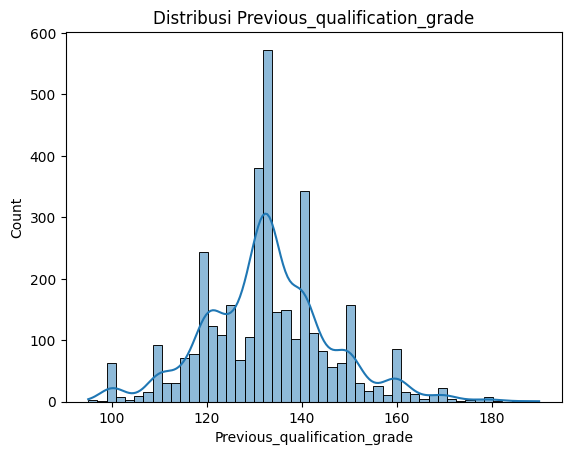

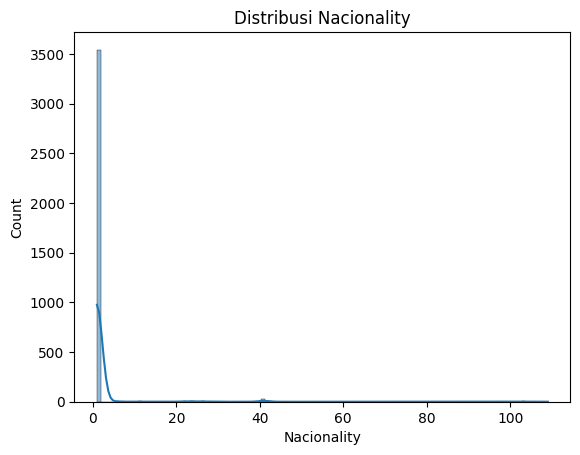

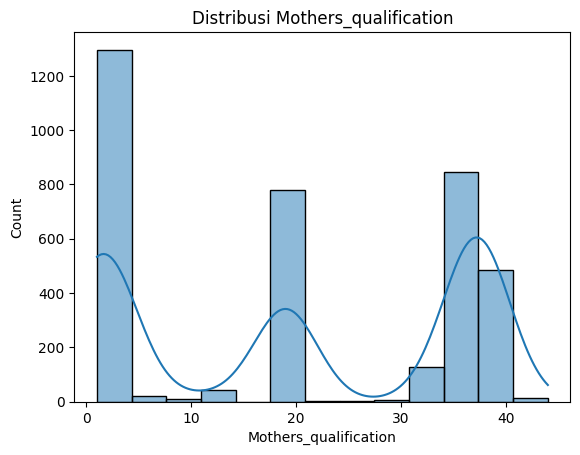

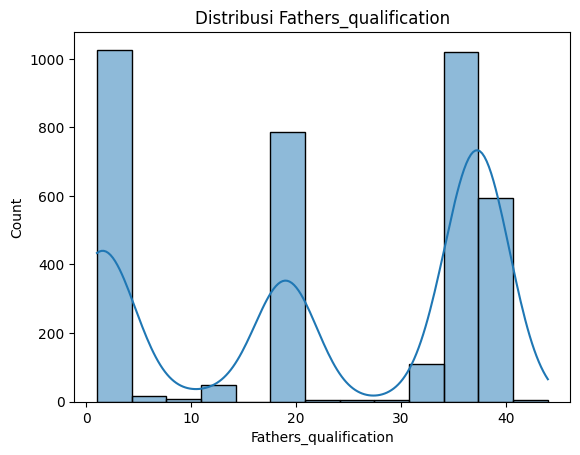

In [24]:
# =========================
# DATA CLEANING (ROBUST VERSION)
# =========================
df = df.copy()

# Drop duplicate
df.drop_duplicates(inplace=True)

# =========================
# CLEAN TARGET (WAJIB)
# =========================
df['Status'] = (
    df['Status']
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Unique Status:", df['Status'].unique())

# =========================
# FILTER TARGET (ANTI ERROR)
# =========================
valid_labels = ['dropout', 'graduate']

df = df[df['Status'].isin(valid_labels)]

# VALIDASI
if df.shape[0] == 0:
    raise ValueError("Data kosong setelah filtering. Cek label Status di dataset.")

# =========================
# MAPPING KE BINARY
# =========================
df['Status'] = df['Status'].map({
    'graduate': 0,
    'dropout': 1
})

target_col = 'Status'

X = df.drop(columns=[target_col])
y = df[target_col]

print("\nDistribusi Target (Binary):")
print(y.value_counts())
print(y.value_counts(normalize=True))

# =========================
# TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain:", X_train.shape)
print("Test:", X_test.shape)

# =========================
# FEATURE ENGINEERING (SAFE)
# =========================
def add_features(df):
    df = df.copy()
    
    df['grade_trend'] = (
        df['Curricular_units_2nd_sem_grade'] -
        df['Curricular_units_1st_sem_grade']
    )
    
    df['avg_grade'] = (
        df['Curricular_units_1st_sem_grade'] +
        df['Curricular_units_2nd_sem_grade']
    ) / 2
    
    df['grade_ratio'] = df['Curricular_units_2nd_sem_grade'] / (
        df['Curricular_units_1st_sem_grade'] + 1
    )
    
    return df

# APPLY SETELAH SPLIT (anti leakage)
X_train = add_features(X_train)
X_test = add_features(X_test)

# =========================
# COLUMN IDENTIFICATION
# =========================

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

# =========================
# PREPROCESSING PIPELINE
# =========================

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# =========================
# MODEL PIPELINE (BINARY)
# =========================

pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

# =========================
# TRAIN MODEL
# =========================
pipeline.fit(X_train, y_train)

print("\nModel berhasil dilatih (Binary Classification)")

# =========================
# PREDICTION
# =========================
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  # probabilitas dropout

# =========================
# TARGET DISTRIBUTION
# =========================

target_dist = y.value_counts()
target_pct = y.value_counts(normalize=True) * 100

display(pd.DataFrame({
    'Count': target_dist,
    'Percentage (%)': target_pct
}))

sns.countplot(x=y)
plt.title("Distribusi Target (0=Graduate, 1=Dropout)")
plt.show()

# =========================
# NUMERICAL VS TARGET
# =========================
df_analysis = X.copy()
df_analysis['Status'] = y

for col in num_cols[:10]:
    plt.figure()
    sns.boxplot(data=df_analysis, x='Status', y=col)
    plt.title(f"{col} vs Dropout (0=Graduate, 1=Dropout)")
    plt.show()

# =========================
# DISTRIBUSI NUMERIK
# =========================
for col in num_cols[:10]:
    plt.figure()
    sns.histplot(df_analysis[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.show()

## Modeling

In [25]:
# =========================
# MODEL CANDIDATES (FINAL)
# =========================
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=14,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )
}

results = []
best_model = None
best_score = -np.inf

# =========================
# CROSS VALIDATION
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, base_model in models.items():

    print(f"\n🔹 Training {name}")
    cv_scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # =========================
        # CALIBRATION (WAJIB)
        # =========================
        model = CalibratedClassifierCV(
            base_model,
            method='sigmoid',
            cv=3
        )

        pipeline_model = ImbPipeline([
            ('preprocessing', preprocessor),
            ('model', model)
        ])

        # TRAIN
        pipeline_model.fit(X_tr, y_tr)

        # VALIDATION
        y_pred = pipeline_model.predict(X_val)
        y_proba = pipeline_model.predict_proba(X_val)[:, 1]

        # =========================
        # METRICS (BALANCED)
        # =========================
        recall = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        roc = roc_auc_score(y_val, y_proba)

        # =========================
        # ANTI OVER-PREDICT DROPOUT
        # =========================
        pred_dist = pd.Series(y_pred).value_counts(normalize=True)
        dropout_ratio = pred_dist.get(1, 0)

        penalty = 0
        if dropout_ratio > 0.7:
            penalty += 0.05
        if dropout_ratio < 0.2:
            penalty += 0.03

        # =========================
        # FINAL SCORING (IMPROVED)
        # =========================
        score = (
            0.35 * f1 +
            0.35 * roc +
            0.30 * recall
        ) - penalty

        cv_scores.append(score)

    final_score = np.mean(cv_scores)
    print(f"{name} CV Score: {final_score:.4f}")

    # =========================
    # FINAL MODEL TRAIN
    # =========================
    final_model = ImbPipeline([
        ('preprocessing', preprocessor),
        ('model', CalibratedClassifierCV(
            base_model,
            method='sigmoid',
            cv=3
        ))
    ])

    final_model.fit(X_train, y_train)

    # =========================
    # TEST EVALUATION
    # =========================
    y_pred_test = final_model.predict(X_test)
    y_proba_test = final_model.predict_proba(X_test)[:, 1]

    recall_test = recall_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    roc_test = roc_auc_score(y_test, y_proba_test)

    results.append({
        "Model": name,
        "pipeline": final_model,
        "CV Score": final_score,
        "Recall": recall_test,
        "F1": f1_test,
        "ROC-AUC": roc_test
    })

    # SELECT BEST
    if final_score > best_score:
        best_score = final_score
        best_model = final_model
        best_model_name = name

# =========================
# HASIL AKHIR
# =========================
results_df = pd.DataFrame(results).sort_values(by="CV Score", ascending=False)
display(results_df)

print("\n🏆 Best Model:", best_model_name)

# =========================
# DISTRIBUSI PREDIKSI (WAJIB)
# =========================
pred_distribution = pd.Series(best_model.predict(X_test)).value_counts(normalize=True)

print("\nDistribusi Prediksi:")
print(pred_distribution)

# =========================
# SANITY CHECK (REAL TEST)
# =========================
print("\nSanity Check Sample:")
sample = X_test.sample(5, random_state=42)
print(best_model.predict_proba(sample))

# =========================
# FEATURE IMPORTANCE (DEBUG WAJIB)
# =========================
try:
    rf_model = best_model.named_steps['model'].base_estimator
    importances = rf_model.feature_importances_

    feature_names = preprocessor.get_feature_names_out()

    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    print("\nTop Features:")
    display(feat_imp.head(15))

except:
    print("Feature importance tidak tersedia untuk model ini")

# =========================
# SAVE MODEL
# =========================
joblib.dump(best_model, 'model.pkl')
joblib.dump(X_train.columns.tolist(), 'columns.pkl')

print("\nModel berhasil disimpan")


🔹 Training Logistic Regression
Logistic Regression CV Score: 0.8804

🔹 Training Random Forest
Random Forest CV Score: 0.8798


,Model,pipeline,CV Score,Recall,F1,ROC-AUC
0,Logistic Regression,"(ColumnTransformer(transformers=[('num',\n ...",0.880407,0.908451,0.926391,0.973098
1,Random Forest,"(ColumnTransformer(transformers=[('num',\n ...",0.879792,0.873239,0.876325,0.965259



🏆 Best Model: Logistic Regression

Distribusi Prediksi:
0    0.623967
1    0.376033
Name: proportion, dtype: float64

Sanity Check Sample:
[[0.72601173 0.27398827]
 [0.98763752 0.01236248]
 [0.01191316 0.98808684]
 [0.94405736 0.05594264]
 [0.97846717 0.02153283]]
Feature importance tidak tersedia untuk model ini

Model berhasil disimpan


## Evaluation

,Model,Accuracy,Precision,Recall (Dropout),F1 Score,ROC-AUC
0,Logistic Regression,0.943526,0.945055,0.908451,0.926391,0.973098
1,Random Forest,0.903581,0.879433,0.873239,0.876325,0.965259



🏆 Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       442
           1       0.95      0.91      0.93       284

    accuracy                           0.94       726
   macro avg       0.94      0.94      0.94       726
weighted avg       0.94      0.94      0.94       726



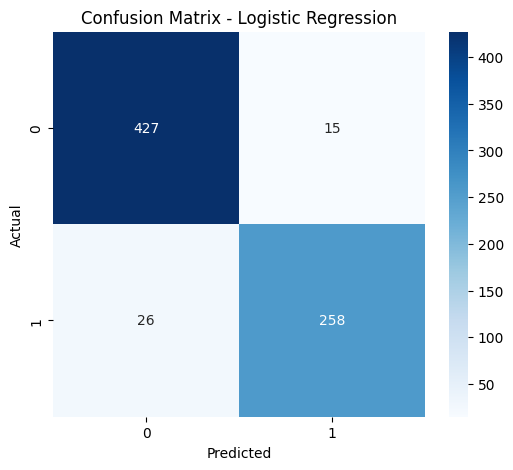

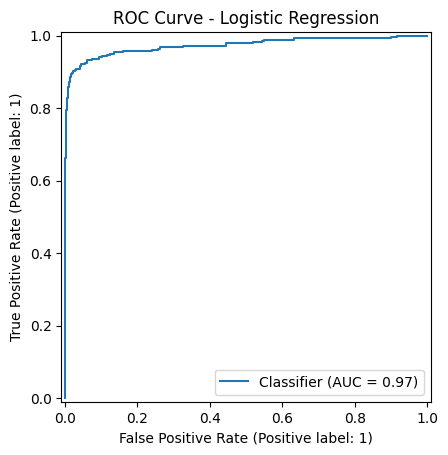

In [ ]:
# =========================
# EVALUATION - FINAL (BINARY)
# =========================


evaluation_results = []

for res in results:
    name = res["Model"]
    pipeline = res["pipeline"]

    # =========================
    # PREDICTION
    # =========================
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]  
    # =========================
    # METRICS (BINARY)
    # =========================
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)             
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    evaluation_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall (Dropout)": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

# =========================
# RESULT TABLE
# =========================
eval_df = pd.DataFrame(evaluation_results)\
    .sort_values(by="Recall (Dropout)", ascending=False)

display(eval_df)

# =========================
# BEST MODEL
# =========================
best_model_name = eval_df.iloc[0]["Model"]

best_pipeline = next(
    item["pipeline"] for item in results if item["Model"] == best_model_name
)

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

print("\n🏆 Best Model:", best_model_name)

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# =========================
# CONFUSION MATRIX
# =========================
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# ROC CURVE (BINARY)
# =========================
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()

,Model,Accuracy,Precision,Recall (Dropout),F1 Score,ROC-AUC
0,Logistic Regression,0.943526,0.945055,0.908451,0.926391,0.973098
1,Random Forest,0.903581,0.879433,0.873239,0.876325,0.965259



🏆 Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       442
           1       0.95      0.91      0.93       284

    accuracy                           0.94       726
   macro avg       0.94      0.94      0.94       726
weighted avg       0.94      0.94      0.94       726



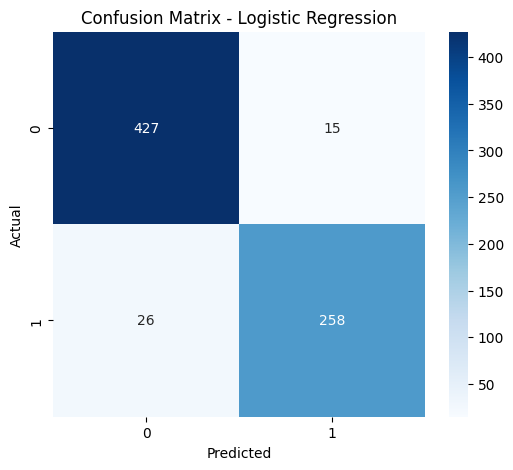

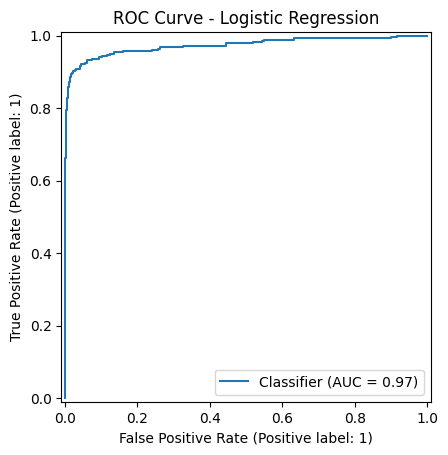

In [30]:
# =========================
# EVALUATION - FINAL (BINARY)
# =========================
evaluation_results = []

for res in results:
    name = res["Model"]
    pipeline = res["pipeline"]

    # =========================
    # PREDICTION
    # =========================
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]  

    # =========================
    # METRICS (BINARY)
    # =========================
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)              
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    evaluation_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall (Dropout)": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

# =========================
# RESULT TABLE
# =========================
eval_df = pd.DataFrame(evaluation_results)\
    .sort_values(by="Recall (Dropout)", ascending=False)

display(eval_df)

# =========================
# BEST MODEL
# =========================
best_model_name = eval_df.iloc[0]["Model"]

best_pipeline = next(
    item["pipeline"] for item in results if item["Model"] == best_model_name
)

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

print("\n🏆 Best Model:", best_model_name)

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# =========================
# CONFUSION MATRIX
# =========================
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# ROC CURVE (BINARY)
# =========================
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()